# Spatial Lapse Rate from Juneau Icefield Temperature Data

### Prep to import Juneau Icefield temperature data at daily resolution

In [1]:
import glob

root_folder = '/Users/badgeley/projects/lapse_rate/Weather_Stations/LVL2/'

# Get only daily files (i.e. no hourly files)
file_list = glob.glob(root_folder+'*_daily*.csv')

print(file_list)
print(len(file_list))

['/Users/badgeley/projects/lapse_rate/Weather_Stations/LVL2/juneauicefieldCamp18AWS_daily_LVL2.csv', '/Users/badgeley/projects/lapse_rate/Weather_Stations/LVL2/juneauicefield1196_daily_LVL2.csv', '/Users/badgeley/projects/lapse_rate/Weather_Stations/LVL2/juneauicefield1293_daily_LVL2.csv', '/Users/badgeley/projects/lapse_rate/Weather_Stations/LVL2/juneauicefield2050_daily_LVL2.csv', '/Users/badgeley/projects/lapse_rate/Weather_Stations/LVL2/juneauicefield1705_daily_LVL2.csv', '/Users/badgeley/projects/lapse_rate/Weather_Stations/LVL2/juneauicefieldCamp17AWS_daily_LVL2.csv', '/Users/badgeley/projects/lapse_rate/Weather_Stations/LVL2/juneauicefield2121_daily_LVL2.csv', '/Users/badgeley/projects/lapse_rate/Weather_Stations/LVL2/juneauicefield1285_daily_LVL2.csv', '/Users/badgeley/projects/lapse_rate/Weather_Stations/LVL2/juneauicefield1618_daily_LVL2.csv', '/Users/badgeley/projects/lapse_rate/Weather_Stations/LVL2/juneauicefield1445_daily_LVL2.csv', '/Users/badgeley/projects/lapse_rate/We

In [2]:
import pandas as pd
pd.get_option("display.max_columns")

def load_dataframe(file_path, index_col):
    
    df = pd.read_csv(file_path, header=0, index_col=index_col)
    
    df.index = pd.DatetimeIndex(df.index)
    
    return df

### Check out one of the files using a pandas dataframe

In [3]:
file_path = file_list[0]

df = load_dataframe(file_path, 'Date')

df.head(10)

,site_temp_min,site_temp_max,site_temp_WMO,site_temp_USGS,Barom,RelHum,WindGustSpeed,WindSpeed,VecAvgWindDir
Date,,,,,,,,,
2012-07-10,-2.1,1.3,-0.4,-1.1,5.9,98.0,NaN,NaN,NaN
2012-07-11,-2.6,1.9,-0.4,-0.8,5.9,97.4,NaN,3.3,NaN
2012-07-12,-1.2,6.1,2.4,3.9,5.9,65.5,NaN,2.5,83.0
2012-07-13,3.5,5.0,4.3,4.3,5.9,95.2,NaN,2.7,132.0
2012-07-14,2.4,8.3,5.3,4.6,5.9,90.1,NaN,0.9,221.0
2012-07-15,4.6,8.3,6.5,7.0,6.0,66.6,NaN,1.7,158.0
2012-07-16,0.7,5.1,2.9,2.1,6.0,99.4,NaN,2.5,NaN
2012-07-17,0.4,7.5,4.0,4.6,6.0,86.1,NaN,1.1,252.0
2012-07-18,3.2,9.4,6.3,6.4,6.0,73.3,NaN,1.5,NaN


In [4]:
# Prep the data to average to annual resolution

df['year'] = df.index.year
df['month'] = df.index.month

df.head(10)

,site_temp_min,site_temp_max,site_temp_WMO,site_temp_USGS,Barom,RelHum,WindGustSpeed,WindSpeed,VecAvgWindDir,year,month
Date,,,,,,,,,,,
2012-07-10,-2.1,1.3,-0.4,-1.1,5.9,98.0,NaN,NaN,NaN,2012,7
2012-07-11,-2.6,1.9,-0.4,-0.8,5.9,97.4,NaN,3.3,NaN,2012,7
2012-07-12,-1.2,6.1,2.4,3.9,5.9,65.5,NaN,2.5,83.0,2012,7
2012-07-13,3.5,5.0,4.3,4.3,5.9,95.2,NaN,2.7,132.0,2012,7
2012-07-14,2.4,8.3,5.3,4.6,5.9,90.1,NaN,0.9,221.0,2012,7
2012-07-15,4.6,8.3,6.5,7.0,6.0,66.6,NaN,1.7,158.0,2012,7
2012-07-16,0.7,5.1,2.9,2.1,6.0,99.4,NaN,2.5,NaN,2012,7
2012-07-17,0.4,7.5,4.0,4.6,6.0,86.1,NaN,1.1,252.0,2012,7
2012-07-18,3.2,9.4,6.3,6.4,6.0,73.3,NaN,1.5,NaN,2012,7


In [5]:
# Average the dataframe to annual resolution

df.groupby('year').mean().head(10)

,site_temp_min,site_temp_max,site_temp_WMO,site_temp_USGS,Barom,RelHum,WindGustSpeed,WindSpeed,VecAvgWindDir,month
year,,,,,,,,,,
2012,-4.700000,-1.233143,-2.964571,-3.001714,6.022286,84.342286,NaN,5.518935,167.206349,9.622857
2013,-7.824706,-3.208235,-5.518824,-5.618235,6.008235,82.782645,NaN,4.452050,154.094340,6.526027
2014,NaN,NaN,NaN,NaN,NaN,80.314972,NaN,5.158559,154.822034,6.526027
2015,NaN,NaN,NaN,NaN,NaN,84.304457,NaN,4.908735,157.256198,6.526027
2016,-4.911475,-1.485246,-3.201639,-3.400000,NaN,82.889426,NaN,5.189241,154.156863,6.513661
2017,-5.302740,-1.225205,-3.267123,-3.604658,NaN,80.522072,NaN,9.071429,104.222222,6.526027
2018,-7.439080,-2.932759,-5.181034,-5.620115,NaN,51.900000,NaN,NaN,NaN,3.408046


### Plot the annually-averaged maximum temperature data for each station on the icefield

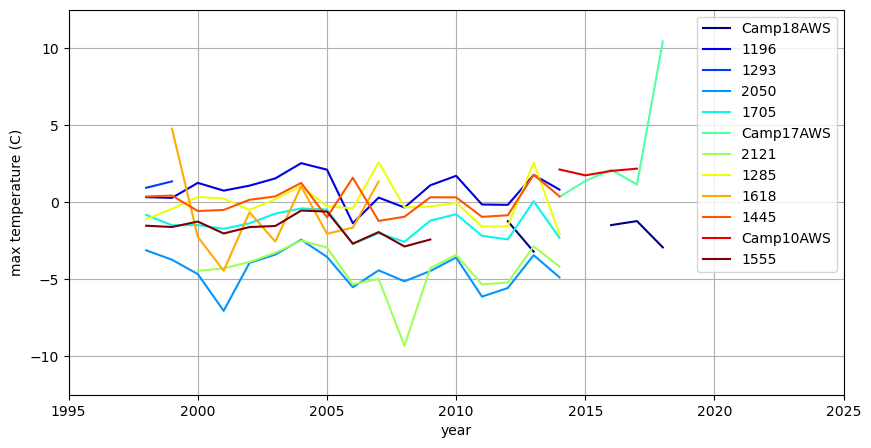

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# define a set of colors to use for plotting
colors = plt.cm.jet(np.linspace(0,1,len(file_list)))

# initiate the figure
plt.figure(figsize=(10,5))

# loop through each station file
for ii, file_path in enumerate(file_list):

    # load data and average to annual resolution,
    df = load_dataframe(file_path, 'Date')
    df['year'] = df.index.year
    df_yr = df.groupby('year').mean()

    # grab the station name from the file name
    label = file_path.split('/')[-1].split('_')[0].split('field')[-1]

    # plot the maximum temperature
    plt.plot(df_yr.index.values, df_yr['site_temp_max'],
             '-', color=colors[ii], label=label)

# define plot parameters
plt.grid()
plt.legend()
plt.xlabel('year')
plt.ylabel('max temperature (C)')
plt.ylim([-12.5,12.5])
plt.xlim([1995,2025])
plt.show()

Is there a relationship between elevation and temperature? (The elevation is the label with units of meters.)

### Plot daily maximum temperatures for each station for the year 2002

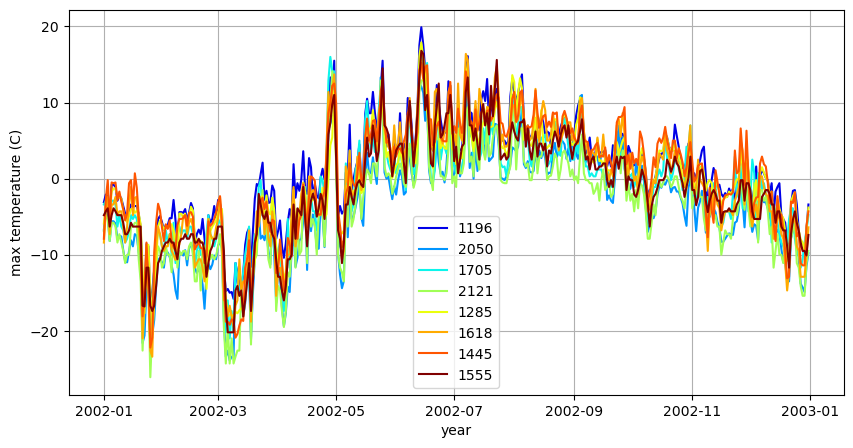

In [7]:
# Define the year of interest (yoi)
yoi = 2002;

# initiate the figure
plt.figure(figsize=(10,5))

# loop through each station file
for ii, file_path in enumerate(file_list):

    # load the file and extract out year and month for each data point
    df = load_dataframe(file_path, 'Date')
    df['year'] = df.index.year
    df['month'] = df.index.month

    # locate the data from the year of interest
    df_yoi = df[df['year']==yoi]

    # drop any NaN's based on our field of interest
    df_yoi_nona = df_yoi['site_temp_max'].dropna()

    # if we have a full year's worth of data, plot it
    # (you can lower this threshold, but recognize there may start to be seasonal biases in your estimate)
    if len(df_yoi_nona) == 365:

        # grab the station name from the file name
        label = file_path.split('/')[-1].split('_')[0].split('field')[-1]

        # plot the date vs maximum temperature for this site in the year of interest
        plt.plot(df_yoi_nona.index.values, df_yoi_nona.values,
                 '-', color=colors[ii], label=label)

# define plot parameters
plt.grid()
plt.legend()
plt.xlabel('year')
plt.ylabel('max temperature (C)')
plt.show()  

### Plot elevation vs. annually-averaged USGS site temperature for the year 2002 and calculate the spatial lapse rate

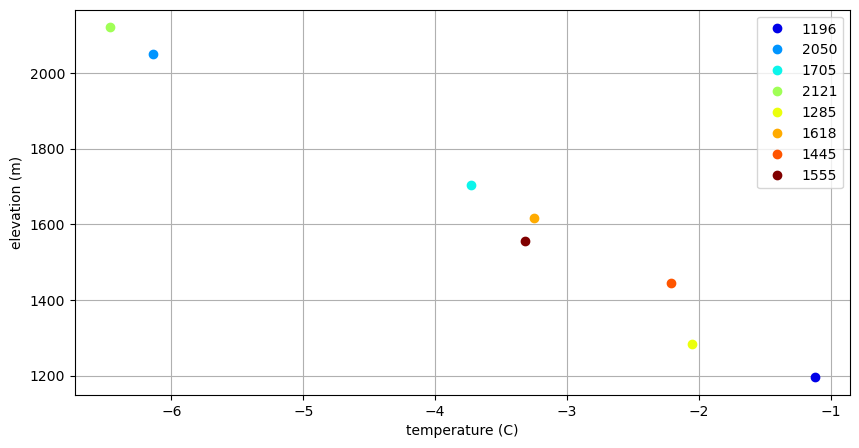

In [8]:
# Define the year of interest
yoi = 2002;

# Prep lists to save elevation and temperature data to
elvs = []
Ts = []

# initiate the figure
plt.figure(figsize=(10,5))

# loop through each station file
for ii, file_path in enumerate(file_list):

    # loat the file and extract out date information
    df = load_dataframe(file_path, 'Date')
    df['year'] = df.index.year
    df['month'] = df.index.month

    # extract out data from our year of interest
    df_yoi = df[(df['year']==yoi)]

    # drop any NaN's based on our field of interest
    df_yoi_nona = df_yoi['site_temp_USGS'].dropna()

    # if the data is complete then...
    if len(df_yoi_nona) == 365:

        # grab the station name, which happens to be it's elevation in meters
        label = file_path.split('/')[-1].split('_')[0].split('field')[-1]
        try:
            elevation = int(label)
        except:
            print('The elevation of this station is currently unknown')
            continue

        # plot the mean annual temperature for this station against it's elevation
        plt.plot(df_yoi_nona.values.mean(), elevation,
                 'o', color=colors[ii], label=label)

        # save the elevation and temperature to our data lists
        elvs = elvs + [int(label)]
        Ts = Ts + [df_yoi_nona.values.mean()]

# define plotting parameters
plt.grid()
plt.legend()
plt.ylabel('elevation (m)')
plt.xlabel('temperature (C)')
plt.show() 

In [9]:
# import a statistics package
from scipy import stats

# set significance threshold
significance_threshold = 0.05

# calculate statistics and display results
r, p_value = stats.pearsonr(elvs,Ts)
print('Correlation Coefficient = '+str(r)+'\nP-value = '+str(p_value))

slope, intercept, r_value, p_value, slope_stderr = stats.linregress(elvs, Ts)

print('Slope = ', slope)
print('Intercept = ', intercept)

Correlation Coefficient = -0.9901290269158612
P-value = 2.3867073147863143e-06
Slope =  -0.005675132817404084
Intercept =  5.668294394391631


#### Questions to consider
Is there a strong and statistically-significant relationship between mean-annual temperature in 2002 and elevation?

Based on the plot and statistic calculated above, what is the lapse rate of the annually-averaged temperature across the icefield in 2002? What are the units?

From this analysis, what would you estimate to be the mean-annual temperature in 2002 of a nearby location at sea level, such as the town of Juneau?

If you try a different year than 2002, do these results change? What if you try a different temperature field, like min or max temperature?

### Plot elevation vs. January USGS site temperature and calculate the spatial lapse rate

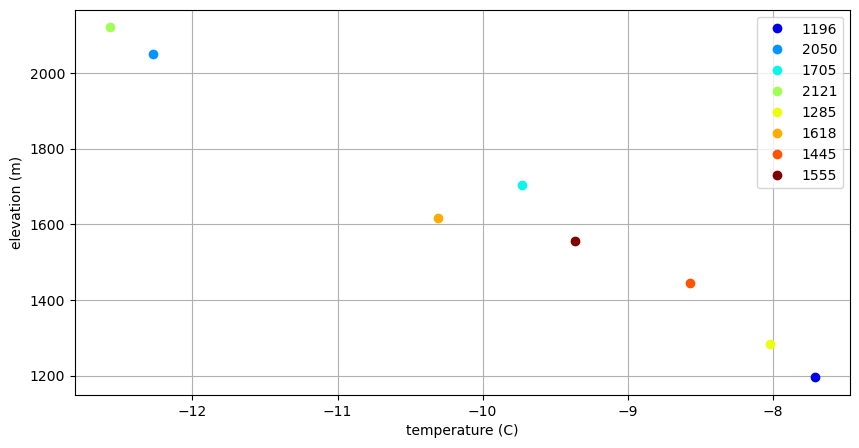

In [10]:
# define the year and month of interest
yoi = 2002;
moi = 1;

# prep lists to save elevation and temperature data to
elvs = []
Ts = []

# initiate the figure
plt.figure(figsize=(10,5))

# loop through the station files
for ii, file_path in enumerate(file_list):

    # load the file and extract date information
    df = load_dataframe(file_path, 'Date')
    df['year'] = df.index.year
    df['month'] = df.index.month
    
    # Choose this line of code to average over one year
    df_yoi = df[(df['year']==yoi) & (df['month']==moi)]
    
    # Choose the next two lines of code to average over all years and ignore the yoi
    #df_moi = df[df['month']==moi]
    #df_yoi = df_moi.groupby('year').mean()

    # drop NaN's based on the field of interest
    df_yoi_nona = df_yoi['site_temp_USGS'].dropna()

    # ensure you have enough data points to have a 'reasonable' monthly average
    if len(df_yoi_nona) > 5:

        # extract the elevation
        label = file_path.split('/')[-1].split('_')[0].split('field')[-1]
        try:
            elevation = int(label)
        except:
            print('The elevation of this station is currently unknown')
            continue

        # plot the the temperature vs elevation
        plt.plot(df_yoi_nona.values.mean(), elevation,
                 'o', color=colors[ii], label=label)

        # save the data for statistical calculations later
        elvs = elvs + [elevation]
        Ts = Ts + [df_yoi_nona.values.mean()]

# Set plotting parameters
plt.grid()
plt.legend()
plt.ylabel('elevation (m)')
plt.xlabel('temperature (C)')
plt.show() 

In [11]:
r, p_value = stats.pearsonr(elvs,Ts)
print('Correlation Coefficient = '+str(r)+'\nP-value = '+str(p_value))

slope, intercept, r_value, p_value, slope_stderr = stats.linregress(elvs, Ts)

print('Slope = ', slope)
print('Intercept = ', intercept)

Correlation Coefficient = -0.984665076224067
P-value = 8.912027549381539e-06
Slope =  -0.005413656102842867
Intercept =  -1.037871669492045


#### Questions to consider
How is this lapse rate similar or different from the annual average?

How does the lapse rate vary with month? 

Does the lapse rate for a given month vary from year-to-year and compared to the average of the whole data record?

#### The following plot and analysis may help you answer some of the above questions more efficiently.

For month 1, the lapse rate is -3.82 C/km
For month 2, the lapse rate is -5.18 C/km
For month 3, the lapse rate is -6.45 C/km
For month 4, the lapse rate is -6.74 C/km
For month 5, the lapse rate is -6.15 C/km
For month 6, the lapse rate is -5.65 C/km
For month 7, the lapse rate is -5.23 C/km
For month 8, the lapse rate is -5.67 C/km
For month 9, the lapse rate is -5.81 C/km
For month 10, the lapse rate is -5.77 C/km
For month 11, the lapse rate is -5.12 C/km
For month 12, the lapse rate is -3.81 C/km


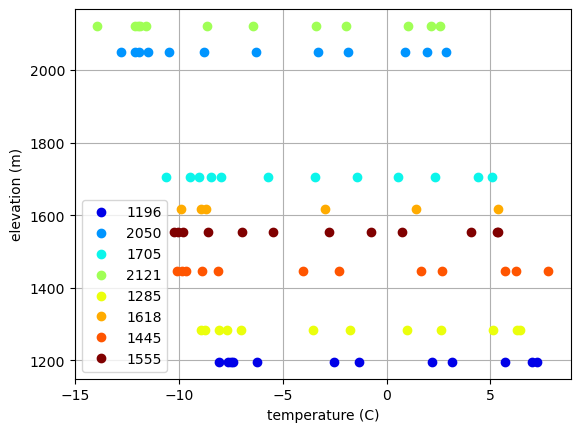

In [12]:
# define the year of interest
yoi = 2002;

# loop through all the months (1-12)
for moi in range(1, 13):
    
    # prep lists to save elevation and temperature data to
    elvs = []
    Ts = []

    # loop through the station files
    for ii, file_path in enumerate(file_list): 
        
        # load data and extract time information
        df = load_dataframe(file_path, 'Date')
        df['year'] = df.index.year
        df['month'] = df.index.month

        # Choose this line of code to average over your year of interest
        #df_yoi = df[(df['year']==yoi) & (df['month']==moi)]

        # Choose the next two lines of code to average over all years
        df_moi = df[df['month']==moi]
        df_yoi = df_moi.groupby('year').mean()

        # drop NaN's based on your variable of interest
        df_yoi_nona = df_yoi['site_temp_USGS'].dropna()

        # ensure you have sufficient data from this site for a meaningful average
        if len(df_yoi_nona) > 5:

            # extract the elevation
            label = file_path.split('/')[-1].split('_')[0].split('field')[-1]
            try:
                elevation = int(label)
            except:
                print('The elevation of this station is currently unknown')
                continue

            # plot
            plt.plot(df_yoi_nona.values.mean(), elevation,
                     'o', color=colors[ii], label=label)

            # save data for statistical calculations
            elvs = elvs + [elevation]
            Ts = Ts + [df_yoi_nona.values.mean()]
    
    r, p_value = stats.pearsonr(elvs,Ts)
    slope, intercept, r_value, p_value, slope_stderr = stats.linregress(elvs, Ts)

    print('For month ' + str(moi) + ', the lapse rate is ' + str(np.round(slope*1000,2)) + ' C/km')

    if moi == 1:
        # Set plotting parameters
        plt.grid()
        plt.legend()
        plt.ylabel('elevation (m)')
        plt.xlabel('temperature (C)')

plt.show() 

#### More questions to consider and a few challenges
How does the seasonality of the lapse rates depend on which temperature you use? For example, what if you use the min and max temperatures instead?

Why do you think the lapse rates have this seasonality? Condsider how temperature impacts humidity and how water vapor impacts the lapse rate.

Can you plot the best-fit line on the graph?

### Can you investigate how lapse rates vary between day and night?

### Where are these stations located?

In [13]:
loc_file_path = '/Users/badgeley/projects/lapse_rate/Weather_Stations/WeatherStationLocations.csv'
df_locs = pd.read_csv(loc_file_path, header=0, index_col='Elevation')

df_locs.head(10)

,Location,Latitude,Longitude,NWIS ID
Elevation,,,,
1196,C-10,59.575640,-133.709820,NaN
1285,C-17,58.647210,-134.206350,NaN
1445,C-26,58.367370,-134.366380,NaN
1555,C-9,59.016640,-134.121040,NaN
1618,C-29,58.712433,-134.182217,NaN
1705,C-18,59.342110,-134.102210,NaN
2050,C-8,58.834970,-134.276430,NaN
2121,C-25,58.806700,-134.136130,NaN


Text(-133, 58.3019, 'Juneau')

/Users/badgeley/miniconda3/envs/jif-lapse-rate/lib/python3.11/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_1_states_provinces_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


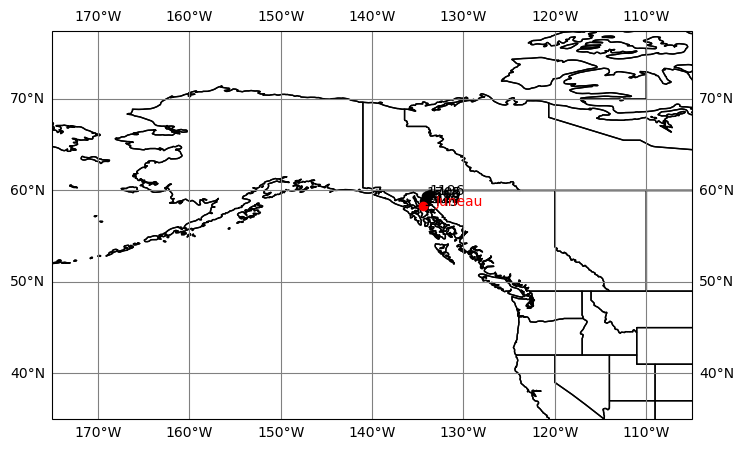

In [18]:
# import the needed packages
import cartopy.crs as ccrs
import cartopy.feature as cf 
from matplotlib.offsetbox import AnchoredText

# define the projection
proj = ccrs.PlateCarree()

# initialize the figure
fig = plt.figure()
ax = fig.add_axes([0, 0, 1, 1], projection=proj)

# set the extent
ax.set_extent([-175, -105, 35, 75], ccrs.Geodetic())

# add spatial references to the plot
ax.gridlines(crs=proj, linestyle='-', color='grey', draw_labels=True)
ax.add_feature(cf.COASTLINE, edgecolor='k', linewidth=1)  
ax.add_feature(cf.STATES, edgecolor='k', linewidth=1) 

# loop through our station locations and plot
for index in df_locs.index.values:
    ax.plot(df_locs.loc[index,'Longitude'],
            df_locs.loc[index,'Latitude'],
            'ko', transform=proj)
    ax.text(df_locs.loc[index,'Longitude'],
            df_locs.loc[index,'Latitude'],
            index,
            color='k', transform=proj)

# show the town of Juneau as reference
ax.plot(-134.4197, 58.3019, 'ro', transform=proj)
ax.text(-133, 58.3019, 'Juneau', color='r', transform=proj)

Text(-134.4197, 58.3019, '17')

/Users/badgeley/miniconda3/envs/jif-lapse-rate/lib/python3.11/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_1_states_provinces_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


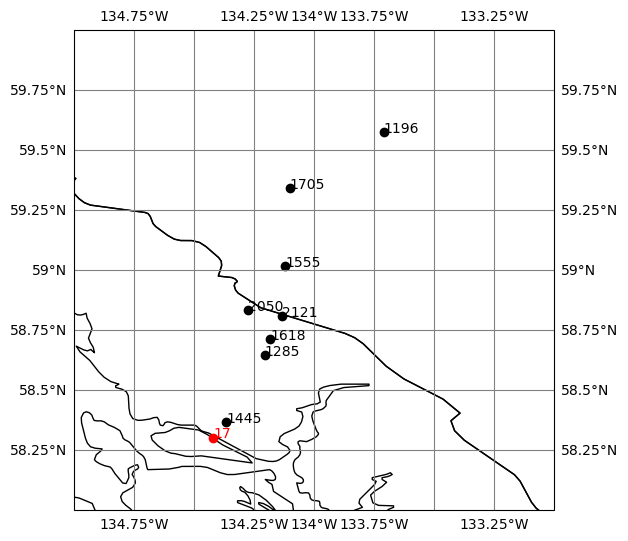

In [17]:
# same thing as above, but zoomed in with an elevation given for Juneau

proj = ccrs.PlateCarree()

fig = plt.figure()
ax = fig.add_axes([0, 0, 1, 1], projection=proj)

ax.set_extent([-135, -133, 58, 60], ccrs.Geodetic())

#ax.add_feature(cf.COASTLINE, edgecolor='k', linewidth=1)  
ax.add_feature(cf.STATES, edgecolor='k', linewidth=1)  
ax.gridlines(crs=proj, linestyle='-', color='grey', draw_labels=True)

for index in df_locs.index.values:
    ax.plot(df_locs.loc[index,'Longitude'],
            df_locs.loc[index,'Latitude'],
            'ko', transform=proj)
    ax.text(df_locs.loc[index,'Longitude'],
            df_locs.loc[index,'Latitude'],
            index,
            color='k', transform=proj)
    
ax.plot(-134.4197, 58.3019, 'ro', transform=proj)
ax.text(-134.4197, 58.3019, '17', color='r', transform=proj)

### Compare the weather station lapse rate results from 2002 to ERA5 reanalysis data
Note: this section needs to be cleaned up and commented. I also have to find or re-download the ERA5 data...

In [ ]:
file_path = '/Users/jabadgeley/JIRP/data/ERA5/'
file_name = 'z_Amon_ERA5_2002.nc'

import xarray as xr
ds_z_full = xr.open_dataset(file_path+file_name)
ds_z = ds_z_full.sel(longitude=slice(-175 % 360, -105 % 360), latitude=slice(75, 35), time='2002-01-01')

z_plot = np.squeeze(ds_z.z.values)

longitudes = ((ds_z['longitude'] + 180) % 360) - 180
meshlons, meshlats = np.meshgrid(longitudes, ds_z.latitude.values)

proj = ccrs.PlateCarree()

fig = plt.figure()
ax = fig.add_axes([0, 0, 1, 1], projection=proj)

ax.set_extent([-135, -133, 58, 60], ccrs.Geodetic())

ax.add_feature(cf.COASTLINE, edgecolor='k', linewidth=1)  
#ax.add_feature(cf.STATES, edgecolor='k', linewidth=1)  
ax.gridlines(crs=proj, linestyle='-', color='grey', draw_labels=True)

cs = ax.pcolormesh(meshlons, meshlats, z_plot/9.81, cmap='viridis', 
                   vmin=0, vmax=2000, transform=proj)

cb = plt.colorbar(cs, ax=ax, pad=.1)
cb.set_label('meters', rotation=270, labelpad=14)

for index in df_locs.index.values:
    ax.plot(df_locs.loc[index,'Longitude'],
            df_locs.loc[index,'Latitude'],
            'ko', transform=proj)
    ax.text(df_locs.loc[index,'Longitude'],
            df_locs.loc[index,'Latitude'],
            index,
            color='k', transform=proj)
    
ax.plot(-134.4197, 58.3019, 'ro', transform=proj)
ax.text(-134.4197, 58.3019, '17', color='r', transform=proj)

In [150]:
file_path = '/Users/jabadgeley/JIRP/data/ERA5/'
file_name = 't2m_Amon_ERA5_1979-2020.nc'

import xarray as xr
ds_t_full = xr.open_dataset(file_path+file_name)
ds_t = ds_t_full.sel(longitude=slice(-175 % 360, -105 % 360), 
                     latitude=slice(75, 35))#, 
                     #time=slice('2002-01-01','2002-12-01')).mean('time')
                     #time = '2002-01-01')

Text(-134.4197, 58.3019, '17')

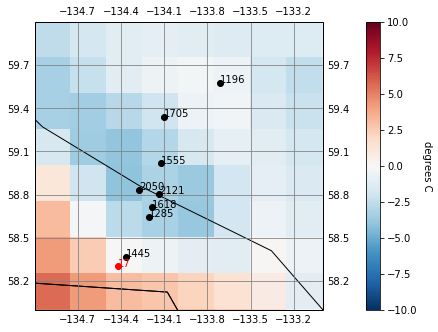

In [152]:
longitudes = ((ds_t['longitude'] + 180) % 360) - 180
meshlons, meshlats = np.meshgrid(longitudes, ds_t.latitude.values)

t_plot = ds_t.t2m.mean('time').values

proj = ccrs.PlateCarree()

fig = plt.figure()
ax = fig.add_axes([0, 0, 1, 1], projection=proj)

ax.set_extent([-135, -133, 58, 60], ccrs.Geodetic())

ax.add_feature(cf.COASTLINE, edgecolor='k', linewidth=1)  
ax.add_feature(cf.STATES, edgecolor='k', linewidth=1)  
ax.gridlines(crs=proj, linestyle='-', color='grey', draw_labels=True)

cs = ax.pcolormesh(meshlons, meshlats, t_plot-273.15, cmap='RdBu_r', 
                   vmin=-10, vmax=10, transform=proj)

cb = plt.colorbar(cs, ax=ax, pad=.1)
cb.set_label('degrees C', rotation=270, labelpad=14)

for index in df_locs.index.values:
    ax.plot(df_locs.loc[index,'Longitude'],
            df_locs.loc[index,'Latitude'],
            'ko', transform=proj)
    ax.text(df_locs.loc[index,'Longitude'],
            df_locs.loc[index,'Latitude'],
            index,
            color='k', transform=proj)
    
ax.plot(-134.4197, 58.3019, 'ro', transform=proj)
ax.text(-134.4197, 58.3019, '17', color='r', transform=proj)

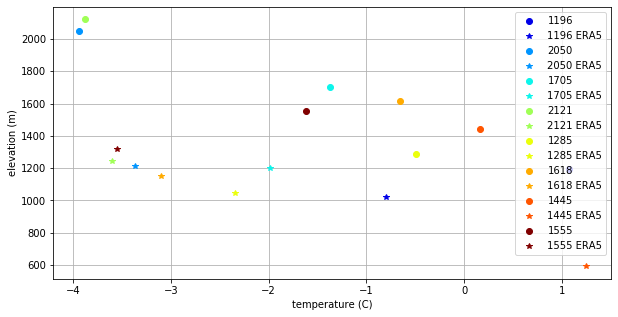

In [153]:
elvs = []
Ts = []
elvs_ERA5 = []
Ts_ERA5 = []

dict_locs = df_locs.to_dict()

plt.figure(figsize=(10,5))

for ii, file_path in enumerate(file_list):
    
    df = load_dataframe(file_path, 'Date')
    df['year'] = df.index.year
    df['month'] = df.index.month
    
    df_2002 = df[(df['year']==2002)]
    
    df_2002_nona = df_2002['site_temp_max'].dropna()
    
    if len(df_2002_nona) == 365:
            
        label = file_path.split('/')[-1].split('_')[0].split('field')[-1]
    
        plt.plot(df_2002_nona.values.mean(), int(label),
                 'o', color=colors[ii], label=label)
        
        lat = dict_locs['Latitude'][int(label)]
        lon = dict_locs['Longitude'][int(label)] % 360
        
        t_loc = ds_t.interp(latitude=lat, longitude=lon, method='linear').sel(time=slice('2002-01-01','2002-12-01')).mean('time')
        z_loc = ds_z.interp(latitude=lat, longitude=lon, method='linear')
        
        plt.plot(t_loc.t2m.values.mean()-273.15, z_loc.z.values.mean()/9.81, '*', color=colors[ii], label=label+' ERA5')
        
        elvs = elvs + [int(label)]
        Ts = Ts + [df_2002_nona.values.mean()]
        elvs_ERA5 = elvs_ERA5 + [z_loc.z.values.mean()/9.81]
        Ts_ERA5 = Ts_ERA5 + [t_loc.t2m.values.mean()-273.15]

plt.grid()
plt.legend()
plt.ylabel('elevation (m)')
plt.xlabel('temperature (C)')
plt.show()     

In [154]:
r, p_value = stats.pearsonr(elvs,Ts)
print('Correlation Coefficient = '+str(r)+'\nP-value = '+str(p_value))
slope, intercept, r_value, p_value, slope_stderr = stats.linregress(elvs, Ts)
print('Slope = ', slope)
print('Intercept = ', intercept, '\n')

r, p_value = stats.pearsonr(elvs_ERA5,Ts_ERA5)
print('ERA5 Correlation Coefficient = '+str(r)+'\nERA5 P-value = '+str(p_value))

slope, intercept, r_value, p_value, slope_stderr = stats.linregress(elvs_ERA5, Ts_ERA5)

print('ERA5 Slope = ', slope)
print('ERA5 Intercept = ', intercept)

Correlation Coefficient = -0.9468971919225281
P-value = 0.00035961118399445685
Slope =  -0.005127540373240108
Intercept =  6.975613104492636 

ERA5 Correlation Coefficient = -0.934129966411392
ERA5 P-value = 0.0006796691515283236
ERA5 Slope =  -0.0069227439614270815
ERA5 Intercept =  5.4136943620663995


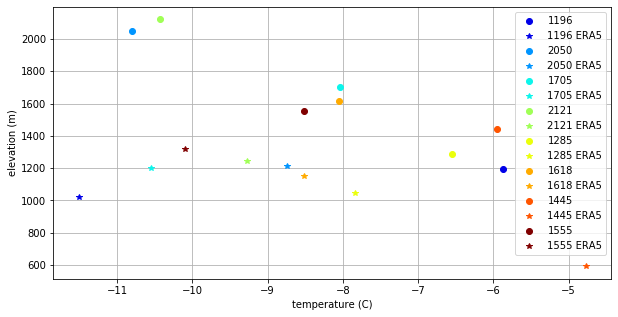

In [157]:
elvs = []
Ts = []
elvs_ERA5 = []
Ts_ERA5 = []

dict_locs = df_locs.to_dict()

plt.figure(figsize=(10,5))

for ii, file_path in enumerate(file_list):
    
    df = load_dataframe(file_path, 'Date')
    df['year'] = df.index.year
    df['month'] = df.index.month
    
    df_2002 = df[(df['year']==2002) & (df['month']==1)]
    
    df_2002_nona = df_2002['site_temp_max'].dropna()
    
    if len(df_2002_nona) > 0:
            
        label = file_path.split('/')[-1].split('_')[0].split('field')[-1]
    
        plt.plot(df_2002_nona.values.mean(), int(label),
                 'o', color=colors[ii], label=label)
        
        lat = dict_locs['Latitude'][int(label)]
        lon = dict_locs['Longitude'][int(label)] % 360
        
        t_loc = ds_t.interp(latitude=lat, longitude=lon, method='linear').sel(time='2002-01-01')
        z_loc = ds_z.interp(latitude=lat, longitude=lon, method='linear')
        
        plt.plot(t_loc.t2m.values.mean()-273.15, z_loc.z.values.mean()/9.81, '*', color=colors[ii], label=label+' ERA5')
        
        elvs = elvs + [int(label)]
        Ts = Ts + [df_2002_nona.values.mean()]
        elvs_ERA5 = elvs_ERA5 + [z_loc.z.values.mean()/9.81]
        Ts_ERA5 = Ts_ERA5 + [t_loc.t2m.values.mean()-273.15]

plt.grid()
plt.legend()
plt.ylabel('elevation (m)')
plt.xlabel('temperature (C)')
plt.show()     

In [158]:
r, p_value = stats.pearsonr(elvs,Ts)
print('Correlation Coefficient = '+str(r)+'\nP-value = '+str(p_value))
slope, intercept, r_value, p_value, slope_stderr = stats.linregress(elvs, Ts)
print('Slope = ', slope)
print('Intercept = ', intercept, '\n')

r, p_value = stats.pearsonr(elvs_ERA5,Ts_ERA5)
print('ERA5 Correlation Coefficient = '+str(r)+'\nERA5 P-value = '+str(p_value))

slope, intercept, r_value, p_value, slope_stderr = stats.linregress(elvs_ERA5, Ts_ERA5)

print('ERA5 Slope = ', slope)
print('ERA5 Intercept = ', intercept)

Correlation Coefficient = -0.9459185485572129
P-value = 0.0003795778803346242
Slope =  -0.005375467234423798
Intercept =  0.6876907595407751 

ERA5 Correlation Coefficient = -0.7372418064206353
ERA5 P-value = 0.03688527117407227
ERA5 Slope =  -0.00665477059672018
ERA5 Intercept =  -1.603720856223105


### Now look at our own data from 2022 and 2023!